**Машинное обучение в экономике**

**Семинар 2. Метод ближайших соседей**

Установка библиотек

In [ ]:
# !python.exe -m pip install --upgrade pip
# !pip install numpy
# !pip install pandas
# !pip install scikit-learn
!pip install kds

In [ ]:
# Подключим необходимые библиотеки
import numpy as np                                        # базовые операции с массивами
import pandas as pd                                       # базовые операции с датафреймами
from   sklearn.naive_bayes import CategoricalNB           # наивный Байесовский классификатор
from   sklearn.model_selection import train_test_split    # разделение выборки на
                                                          # обучающую и тестовую
from   sklearn.model_selection import cross_val_score     # кросс-валидация
from   sklearn.model_selection import KFold               # разбиение на части (folds)
import openpyxl                                           # работа с excel
import matplotlib.pyplot as plt                           # графики
from   sklearn.metrics import confusion_matrix            # подсчет прогнозов
from   sklearn.neighbors import KNeighborsClassifier      # метод ближайшие соседей
import sklearn
from   sklearn.model_selection import GridSearchCV        # подбор гиперпараметров
from   sklearn.model_selection import RandomizedSearchCV  # подбор гиперпараметров
import scipy                                              # распределения
from   sklearn.metrics import RocCurveDisplay             # ROC-кривая
from   sklearn import metrics                             # метрики точности
import itertools
import kds                                                # выигрыш (gain)
from   sklearn.utils import shuffle                       # случайная перестановка
from   sklearn.inspection import DecisionBoundaryDisplay  # границы решений

**Рассматриваемые методы**

1. Метод ближайших соседей

**Рассматриваемые техники**

1. Нормализация данных.
2. Тюнинг гиперпараметров.
3. Сравнение моделей с учетом цен прогнозов.
4. Подбор оптимального порога для прогнозирования.
5. ROC-кривая и AUC.
6. Выигрыш (gain) и подъем (lift).




**Генерация данных** 🐰

In [ ]:
# Для воспроизводимости
np.random.seed(777)

# Число наблюдений
n = 1000

# Названия переменных
features_names = ["age", "educ", "married", "nchildren", "work", "income"]

# Число признаков
m = len(features_names)

# Ковариации
sigma = pd.DataFrame(np.ones(shape=(m, m), dtype = 'object'),
                     index = features_names,
                     columns = features_names)
  # age
sigma.loc["age", "educ"]      = 0.3
sigma.loc["age", "married"]   = 0.4
sigma.loc["age", "nchildren"] = 0.5
sigma.loc["age", "work"]      = 0.3
sigma.loc["age", "income"]    = 0.4
  # educ
sigma.loc["educ", "married"]   = 0.3
sigma.loc["educ", "nchildren"] = -0.1
sigma.loc["educ", "work"]      = 0.5
sigma.loc["educ", "income"]    = 0.6
  # married
sigma.loc["married", "nchildren"] = 0.5
sigma.loc["married", "work"]      = 0.3
sigma.loc["married", "income"]    = 0.2
  # nchildren
sigma.loc["nchildren", "work"]   = 0.1
sigma.loc["nchildren", "income"] = 0.1
  # work
sigma.loc["work", "income"] = 0.7

# Делаем нижнюю и верхнюю части ковариационной
# матрицы симметричными
for i in range(0, m):
  for j in range(0, i):
    sigma.iloc[i, j] = sigma.iloc[j, i]

# Генирируем данные из многомерного нормального распределения
df = np.random.multivariate_normal(mean = np.zeros(m), cov = sigma, size = n)
df = pd.DataFrame(df)
df.columns = features_names

# Приводим данные к реалистичному виду
  # age
df["age"] = pd.cut(df.loc[:, "age"],
                   bins = scipy.stats.norm.ppf
                     (
                     np.linspace(start = 0, stop = 1, num = 42),
                                 loc = 0, scale = 1
                     ),
                   labels = range(20, 61)
                  )
  # educ
df["educ"] = pd.cut(df.loc[:, "educ"],
                    bins = scipy.stats.norm.ppf
                      (
                        [0, 0.6, 0.9, 1],
                        loc = 0, scale = 1
                      ),
                      labels = range(1, 4)
                   )
  # married
df["married"] = pd.cut(df.loc[:, "married"],
                       bins = scipy.stats.norm.ppf
                         (
                           [0, 0.4, 1],
                           loc = 0, scale = 1
                         ),
                       labels = range(0, 2)
                      )
  # nchildren
df["nchildren"] = pd.cut(df.loc[:, "nchildren"],
                         bins = scipy.stats.norm.ppf(
                           np.concatenate
                             (
                               (
                                 [0],
                                 scipy.stats.poisson.cdf(k = range(0, 10),
                                                         mu = 2),
                                 [1]
                               )
                             ),
                           loc = 0, scale=  1),
                           labels = range(0, 11)
                        )
  # work
df["work"] = pd.cut(df.loc[:, "work"],
                    bins = scipy.stats.norm.ppf
                             (
                              [0, 0.3, 1],
                              loc = 0, scale = 1
                             ),
                    labels = range(0, 2)
                    )
  # income
df["income"] = np.round(
                         scipy.stats.expon.ppf
                           (
                             scipy.stats.norm.cdf(df["income"]), scale = 10
                           )
                       ) + 10

# Конвертируем данные в нужный формат
df = df.astype(float)

# Симулируем покупки
buy_li = (
           2.15                        -
           0.03 * df["age"]            +
           0.00005 * df["age"] ** 2    -
           0.6 * (df["educ"] == 2.0)   -
           0.8 * (df["educ"] == 3.0)   +
           0.5 * df["married"]         +
           0.2 * df["nchildren"]       -
           0.6 * df["work"]            -
           0.5 * np.log(df["income"])  +
           0.02 * np.log(df["income"]) * df["nchildren"]
          )
buy_prob = scipy.stats.t.cdf(buy_li * 1.2, df = 5)
df["buy"] = np.random.binomial(n = 1, p = buy_prob, size = n)

# Доля покупок
print({'buy': np.mean(df["buy"])})

# Корреляционная матрица
print(df.astype(float).corr(method = 'pearson'))

# Данные
print(df)

{'buy': np.float64(0.394)}
                age      educ   married  nchildren      work    income  \
age        1.000000  0.206593  0.334814   0.517540  0.188328  0.302118   
educ       0.206593  1.000000  0.187461  -0.075613  0.301332  0.496044   
married    0.334814  0.187461  1.000000   0.378699  0.239349  0.142047   
nchildren  0.517540 -0.075613  0.378699   1.000000  0.053946  0.108237   
work       0.188328  0.301332  0.239349   0.053946  1.000000  0.439230   
income     0.302118  0.496044  0.142047   0.108237  0.439230  1.000000   
buy       -0.108994 -0.327635  0.085718   0.192214 -0.314806 -0.286803   

                buy  
age       -0.108994  
educ      -0.327635  
married    0.085718  
nchildren  0.192214  
work      -0.314806  
income    -0.286803  
buy        1.000000  
      age  educ  married  nchildren  work  income  buy
0    32.0   2.0      1.0        2.0   1.0    31.0    0
1    23.0   2.0      1.0        0.0   0.0    17.0    0
2    38.0   2.0      1.0        0.0   1

**Первичный анализ данных** 🐱

**Цели** ⭐

*   Изучить данные.  

Описание данных

*   `buy`       - покупка: 0 - не совершена, 1 - совершена.
*   `age`       - возраст в годах.
*   `educ`      - уровень образовнания: 1 - среднее общее, 2 - среднее специальное, 3 - высшее.
*   `married`   - семейный статус: 0 - не в браке, 1 - в браке.
*   `nchildren` - количество детей.
*   `work`      - занятость: 0 - не работает, 1 - работает.
*   `income`    - доход в тысячах рублей.

In [ ]:
# Сохраним число наблюдений
n = df.index.size

# Разделим целевую переменную и признаки
target   = df.loc[:, ['buy']]                   # целевая переменная
features = df.loc[:, df.columns.drop('buy')]    # матрица признаков  все строки, все столбики кроме buy
target   = np.squeeze(target)                   # преобразуем из вектора столбца
                                                # в одномерный массив

# Посмотрим первые несколько строк в данных
df.head(10)

,age,educ,married,nchildren,work,income,buy
0,32.0,2.0,1.0,2.0,1.0,31.0,0
1,23.0,2.0,1.0,0.0,0.0,17.0,0
2,38.0,2.0,1.0,0.0,1.0,24.0,0
3,28.0,1.0,1.0,1.0,0.0,11.0,1
4,48.0,1.0,0.0,1.0,1.0,29.0,0
5,27.0,1.0,0.0,2.0,0.0,11.0,1
6,47.0,1.0,1.0,4.0,0.0,20.0,1
7,27.0,1.0,0.0,1.0,1.0,11.0,1
8,49.0,1.0,1.0,2.0,1.0,20.0,1
9,57.0,3.0,1.0,4.0,1.0,33.0,0


**Метод ближайших соседей** 🐱

**Цели** ⭐

*   Нормализовать данные.  
*   Обучить метод ближайших соседей.
*   Оценить условные вероятности покупок.
*   Спрогнозировать покупки.
*   Оценить точность прогнозов.


Техническое примечание ⚡

Функция `train_test_split()` в качестве индексов наблюдений датафреймов, отражающих тестовую и обучающую выборки, использует индексы исходной выборки. Это может создавать проблемы при попытке выбрать в обучающей и тестовой выборках определенные строки. Например, 10-я строка исходной выборки могла попасть в обучающую выборку в качестве 2-й строки. Однако, при попытке выбрать 2-ю строку в обучающей выборке с помощью, например, метода `.loc`, будет осуществлена попытка выбрать 2-ю строку исходной выборки, что приведет к одному из двух нежелательных сценариев:

*   Если 2-я строка исходной выборки попала в обучающую, то вместо 2-й строки обучающей выборки мы выберем 2-ю строку исходной выборки.
*   Если 2-я строка не попала в обучающую выборку, то мы получим ошибку.

Чтобы сбросить индексы и не сталкиваться с соответствующей проблемой можно применить метод `reset_index()` с параметром `drop = True`, что позволит избежать создания лишнего столбца, дублирующего индексы наблюдений в датафрейме.

In [ ]:
# Разделим выборку на обучающую и тестову
features_train, features_test, target_train, target_test = train_test_split(
    features, target, test_size = 0.2, random_state = 777)

# Сохраним число наблюдений обучающей и тестовой выборок
n_train = len(target_train)
n_test  = len(target_test)

# Вернем исходную сортировку индексов
features_train = features_train.reset_index(drop = True)
target_train   = target_train.reset_index(drop = True)
features_test  = features_test.reset_index(drop = True)
target_test    = target_test.reset_index(drop = True)

Обозначим через $X_{*j}$ столбец $j$ в матрице признаков $X$, то есть $j$-й признак. Через $\tilde{X}$ обозначим матрицу нормализованных признаков.

Наиболее распространенный способ нормализации данных:
$\tilde{X}_{ij} = \frac{X_{ij} - \overline{X}_{*j}}{\sqrt{\hat{\sigma}^{2}_{j}}}$

Где:

*   Выборочное среднее $j$-го признака: $\overline{X}_{*j} = \frac{1}{n}\sum\limits_{i=1}^{n}X_{ij}$
*   Исправленная выборочная дисперсия $j$-го признака: $\hat{\sigma}^{2}_{j} = \frac{1}{n-1} \sum\limits_{i=1}^{n}(X_{ij} - \overline{X}_{*j})^2$

**Важно** - если выборка разделена на обучающую и тестовую, то нормализация признаков тестовой выборки часто осуществляется с помощью выборочных средних и выборочных дисперсий, посчитанных на обучающей выборке.

**Примечание** - в дальнейшем для краткости обозначений будем везде использовать $X$ вместо $\tilde{X}$, но помня о том, что данные были нормализованы.



Техническое примечание ⚡

Сперва создается объект `scaler`, позволяющий стандартизировать данные опираясь на характеристики распределения признаков `features`. Затем с помощью метода `transform()` осуществляется стандартизация признаков `features`.

То, что сперва применяется метод `fit()`, а лишь затем метод `transform()`, связано с тем, что иногда удобно стандартизировать признаки из **тестовой** выборки `features_test` (подаются в `transform`), вычитая выборочное среднее и деля на выборочное стандартное отклонение признаков из **обучающей** выборки `features_train`. Это обусловлено тем, что именно со стандартизированными на характеристики признаков обучающей выборки был обучен работать используемый для классификации метод.

Дополнительная информация может быть найдена в [документации](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html).

In [ ]:
# Сохраним данные до нормализации
features_train_initial = features_train.copy()
features_test_initial  = features_test.copy()

# Подготовим объект, осуществляющий нормализацию
scaler = sklearn.preprocessing.StandardScaler().set_output(transform = "pandas").fit(features_train) #.set_output(transform = "pandas") - указываем
#что мы явно возвращаем pandasDataframe, вместо массива numpy, который возвращается по дефолту

# Нормализуем данные
features_train = scaler.transform(features_train_initial)  # обучающая выборка
features_test  = scaler.transform(features_test_initial)   # тестовая выборка

Техническое примечание ⚡

Функция `KNeighborsClassifier()` возвращает объект, который можно использовать для обучения метода ближайших соседей, с целью последующего прогнозирования и оценивания качества модели.

Основные аргументы:


*   `n_neighbors` - число ближайших соседей. Чем оно больше, тем выше смещение и ниже дисперсия оценок. В результате малое число ближайших соседей может привести к проблеме переобучения, поскольку прогноз строится по малому числу схожих наблюдений.
*   `metric` - метрика расстояния, используемая для расчета дистанции между наблюдениями.
*   `p` - параметр метрики расстояния.

Подробней о функции `KNeighborsClassifier()` можно прочитать в [документации](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html).

In [ ]:
# Воспользуемся методом ближайших соседей
knn = KNeighborsClassifier(n_neighbors = 3,           # число соседей
                           metric      = "minkowski", # метрика расстояния
                           p           = 2)           # Евклидова метрика
knn.fit(features_train, target_train)                 # обучение на данных

KNeighborsClassifier(n_neighbors=3)

Оценим условные вероятности покупок:

$$p_{i} = P(\text{Buy} = 1 | X_{i}) = P(\text{Buy} = 1 | \text{Educ} = \text{Eudc}_{i}, ..., \text{Age} = \text{Age}_{i})$$

Техническое примечание ⚡

Все классы в библиотеке `sklearn` устроены схожим образом и часто наследуют одни и те же методы. Например, и метод ближайших соседей `KNeighborsClassifier()` и наивный байесовский классификатор `CategoricalNB()` используют для оценивания условных вероятностей один и тот же метод `predict_proba()`, в качестве аргумента принимающий матрицу признаков.

In [ ]:
# Оцениваем вероятности
prob_knn = knn.predict_proba(features_train)
print(prob_knn[0:10:, 0])                             # оценки P(Y = 0 | X = x)
print(prob_knn[0:10:, 1])                             # оценки P(Y = 1 | X = x)

[0.         1.         0.66666667 1.         0.33333333 1.
 1.         0.33333333 0.         1.        ]
[1.         0.         0.33333333 0.         0.66666667 0.
 0.         0.66666667 1.         0.        ]


Получим прогнозные значения:

$$\widehat{\text{Buy}}_{i} = \begin{cases}1\text{, если }\hat{p}_{i}\geq 0.5\\0\text{, в противном случае}\end{cases}$$

In [ ]:
# Прогнозы
prediction_knn = knn.predict(features_train)   # I(P(Y = 1 | X = x) > 0.5)
print(prediction_knn[0:10])

#пр дефолту порог 0.5, чтобы сделать кастомный:
# probs = knn.predict_proba(features_train)[:, 1]  - вероятность класса 1
# prediction_custom = (probs >= 0.7).astype(int)    -  порог 0.7

[1 0 0 0 1 0 0 1 1 0]


Оценим точность прогнозов на обучающей и тестовой выборках:

$$\text{ACC} = \frac{1}{n}\sum\limits_{i=1}^{n}I(\text{Buy}_{i} = \widehat{\text{Buy}}_{i})$$

In [ ]:
# Оценим точность
ACC_knn_train = sklearn.metrics.accuracy_score(prediction_knn, target_train)  # обучающая выборка
ACC_knn_test  = knn.score(features_test, target_test)    # тестовая выборка

# Посмотрим на результат
print(pd.DataFrame(data    = [ACC_knn_train, ACC_knn_test],
                   index   = ['Обучающая выборка', 'Тестовая выборка'],
                   columns = ['ACC']))

                       ACC
Обучающая выборка  0.83625
Тестовая выборка   0.67000


**Самостоятельный поиск ближайших соседей** 🐱

**Цели** ⭐

*   Самостоятельно найти трех ближайших соседей для одного из наблюдений в выборке.

Найдем ближайших соседей используя расстояние Евклида:

$$d(x, y) = \sqrt{\frac{1}{m}\sum\limits_{i=1}^{m}(x_{i} - y_{i})^{2}}$$

In [ ]:
# Посчитаем Евклидово расстояние от первого наблюдения
# тестовой выборки до всех наблюдений в обучающей
d = np.sqrt(((features_test.loc[0, :] - features_train) ** 2).mean(axis = 1))
#features_test.loc[0, :] - features_train — вычитаем из тестового вектора (172,68) каждую строку обучающей выборки. Получим матрицу разностей (5 строк, 2 колонки):
#Для индекса 0: (172-170, 68-65) = (2, 3)
#Для индекса 1: (172-180, 68-80) = (-8, -12)

#np.argsort(d) возвращает индексы элементов массива d, отсортированные по возрастанию расстояний. Для наших d:
nn = np.argsort(d)[:3]

# Сравним наблюдение и его ближайших соседей
print(pd.concat([features_test_initial.loc[[0], :],
                 features_train_initial.loc[nn, :]]))

      age  educ  married  nchildren  work  income
0    52.0   1.0      1.0        3.0   0.0    16.0
449  55.0   1.0      1.0        3.0   0.0    15.0
166  49.0   1.0      1.0        3.0   0.0    15.0
359  49.0   1.0      1.0        3.0   0.0    13.0


In [ ]:
# Найдем ближайшего соседа с помощью автоматической функции
nn_auto = knn.kneighbors(features_test.iloc[0:1, :].values,
                         return_distance = False)

# Сравним результаты
print(pd.DataFrame(data    = np.array([np.array(nn).flatten(),
                                       nn_auto.flatten()]).transpose(),
                   index   = ['Первый сосед', 'Второй сосед', 'Третий сосед'],
                   columns = ['Наш результат',
                              'Результат встроенной функции']))

              Наш результат  Результат встроенной функции
Первый сосед            449                           449
Второй сосед            166                           166
Третий сосед            359                           359


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# Изучим значения целевой переменной соседей
print(target_train[nn])

449    1
166    0
359    1
Name: buy, dtype: int64


Оценим условную вероятность покупки:

$$\hat{P}(Y_{i} = 1 | X_{i}) = \frac{N_{Y}}{k}$$

где:

*   $k$ - число ближайших соседей
*   $N_{Y}$ - количество $1$ среди ближайших соседей.



In [ ]:
# Оценим условную вероятность
p_cond = np.mean(target_train[nn])

# Посмотрим на условную вероятность
print(p_cond)

0.6666666666666666


In [ ]:
# Сделаем прогноз и сравним его с истинным значением
nn_prediction = (p_cond >= 0.5).astype(int)
print(pd.DataFrame(data    = [target_test[0], nn_prediction],
                   index   = ['Истина', 'Прогноз'],
                   columns = ['Buy']))

         Buy
Истина     1
Прогноз    1


**Тюнинг гиперпараметров метода ближайших соседей** 🐱

**Цели** ⭐

*   Подобрать оптимальное число соседей и метрику расстояний (гиперпараметры) с помощью кросс-валидации.
*   Сравнить два способа подбора гиперпараметров.


Техническое примечание ⚡

Метод `get_params()` позволяет получить список гиперпараметров модели и их значений.

In [ ]:
# Гиперпараметры модели
knn.get_params()

{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 3,
 'p': 2,
 'weights': 'uniform'}

Поскольку вычислительные мощности исследователя ограничены, то перебрать все возможные значения всех гиперпараметров, на практике, оказывается чрезвычайно сложно.

В качестве альтернативы исследователь выбирает несколько наиболее важных гиперпараметров и ограниченное число их возможных значений, что существенно экономит время на оптимизацию (тюнинг).

В качестве гиперпараметров рассмотрим:


*   `n_neighbors` - число соседей: 3, 5 или 7.
*   `p` - параметр метрики расстояния Минковского: 1 (Манхэттан), 2 (Евклид) и 3.



In [ ]:
# Перебираемые значения гиперпараметров
hyperparameters = {'n_neighbors': [3, 5, 7], 'p': [1, 2, 3]}

Техническое примечание ⚡

Подбор гиперпараметров осуществляется с помощью функции `GridSearchCV()`, которая перебирает все возможные значения гиперпараметров из заранее заданного списка (грида).

Основные аргументы:


*   `estimator` - модель, для которой подбираются гиперпараметры.
*   `param_grid` - лист, в котором указаны подбираемые гиперпараметры и их возможные значения.
*   `scoring` - метрика, на основании которой с помощью кросс-валидации будет выбрано оптимальное значение гиперпараметров.
*   `cv` - количество частей (folds) в кросс-валидации.

С помощью метода `fit()` осуществляется подбор гиперпараметра на конкретных данных.

Дополнительная информация может быть найдена в [документации](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html).

Дополнительные примеры тюнинга параметров можно найти на [странице](https://scikit-learn.org/stable/modules/grid_search.html).


In [ ]:
# Перебор гиперпараметров с помощью кросс-валидации
GSCV_knn = GridSearchCV(estimator  = knn,              # модель
                        param_grid = hyperparameters,  # перебираемые гиперпараметры
                        scoring    = "accuracy",       # метрика качества модели
                        cv         = 5)                # число фолдов в кросс-валидации
GSCV_knn.fit(features_train, target_train)             # подбор гиперпараметров
                                                       # на конкретных данных

GridSearchCV(cv=5, estimator=KNeighborsClassifier(n_neighbors=3),
             param_grid={'n_neighbors': [3, 5, 7], 'p': [1, 2, 3]},
             scoring='accuracy')

Техническое примечание ⚡

Свойство `best_params_` представляет собой лист, содержащий информацию об оптимальных (подобранных) значениях гиперпараметров.

In [ ]:
# Достанем гиперпараметры, соответствующие лучшей модели
hyperparameters_best = GSCV_knn.best_params_
print(hyperparameters_best)

{'n_neighbors': 7, 'p': 3}


In [ ]:
# Обучим модель с лучшими гиперпараметрами
knn2 = KNeighborsClassifier(n_neighbors = hyperparameters_best["n_neighbors"],
                            metric      = "minkowski",
                            p           = hyperparameters_best["p"])
knn2.fit(features_train, target_train)

KNeighborsClassifier(n_neighbors=7, p=3)

In [ ]:
# Оценим точность модели с подобранными гиперпараметрами
ACC_knn2_train = knn2.score(features_train, target_train)  # обучающая выборка
ACC_knn2_test  = knn2.score(features_test, target_test)    # тестовая выборка
ACC_GRD_test = sklearn.metrics.accuracy_score(GSCV_knn.predict(features_test), target_test)

# Сравним точность с исходными и подобранными гиперпараметрами
print(pd.DataFrame(data    = [ACC_knn_test, ACC_knn2_test, ACC_GRD_test],
                   index   = ['Исходные гиперпараметры',
                              'Подобранные гиперпараметры', 'На серче'],
                   columns = ['ACC тестовой выборки']))

                            ACC тестовой выборки
Исходные гиперпараметры                    0.670
Подобранные гиперпараметры                 0.745
На серче                                   0.745


Техническое примечание ⚡

Функция `RandomizedSearchCV()` ищет оптимальные гиперпараметры не перебирая значения гиперпараметров из заранее известного списка, а выбирая их случайным образом из заданного распределения.

Основные аргументы:

*   `param_distributions` - словарь с информацией о распределении гиперпараметров.
*   `n_iter` - число случайно выбираемых значений гиперпараметров. Чем больше это число, тем больше различных значений гиперпараметров переберет алгоритм, но тем больше времени займет выбор наилучшего из них.

Данный способ удобен в случаях, когда исследователю сложно заранее определить ограниченное число потенциально оптимальных значений гиперпараметров, поэтому в качестве альтернативы он случайным образом перебирает эти значения, генерируя их из некоторого распределения.

In [ ]:
# Зададим распределения, из которых будут генерироваться
# значения гиперпараметров.
hyperparameters2 = dict(n_neighbors = scipy.stats.poisson(mu = 2, loc = 1),
                        p           = scipy.stats.geom(p = 0.5, loc = 1))

In [ ]:
# Подбор гиперпараметров с помощью рандомизированного поиска
RPCV_knn = RandomizedSearchCV(estimator           = knn,
                              param_distributions = hyperparameters2,
                              scoring             = "accuracy",
                              cv                  = 5,
                              n_iter              = 10) # число симуляций
RPCV_knn.fit(features, target)                          # подбор гиперпараметров
                                                        # на конкретных данных

RandomizedSearchCV(cv=5, estimator=KNeighborsClassifier(n_neighbors=3),
                   param_distributions={'n_neighbors': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7dd6cd3d67b0>,
                                        'p': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7dd6cd1d4ad0>},
                   scoring='accuracy')

In [ ]:
# Достанем гиперпараметры, соответствующие лучшей модели
print(RPCV_knn.best_params_)

{'n_neighbors': 3, 'p': 2}


In [ ]:
# Сравним результаты двух подходов к поиску гиперпараметров
print(pd.DataFrame(data    = [GSCV_knn.best_score_, RPCV_knn.best_score_],
                   index   = ['GSCV', 'RPCV'],
                   columns = ['ACC-CV']))

       ACC-CV
GSCV  0.69125
RPCV  0.66500


**Оценивание прибыли прогноза** 🐱

**Цели** ⭐

*   Посчитать количество прогнозов различного вида.
*   Оценить прибыль модели с учетом цен прогнозов различного типа.


Запишем возможные виды прогнозов в контексте нашей задачи:


*   **TP (true positive)** - спрогнозировали, что индивид совершит покупку и он на самом деле совершил покупку: $$\text{Buy}_{i} = 1\qquad \widehat{\text{Buy}}_{i}=1$$
*   **TN (true negative)** - спрогнозировали, что индивид не совершит покупку и он на самом деле ее не совершил: $$\text{Buy}_{i} = 0\qquad \widehat{\text{Buy}}_{i}=0$$
*   **FP (false positive)** - спрогнозировали, что индивид совершит покупку, а он на самом деле ее не совершил: $$\text{Buy}_{i} = 0\qquad \widehat{\text{Buy}}_{i}=1$$
*   **FN (false negative)** - спрогнозировали, что индивид не совершит покупку, а он на самом деле ее совершил: $$\text{Buy}_{i} = 1\qquad \widehat{\text{Buy}}_{i}=0$$


In [ ]:
# Получим прогнозы на тестовой выборке с помощью модели
# с подобранными значениями гиперпараметров
prediction_test_knn2 = knn2.predict(features_test)

# Рассмотрим прогнозы различного вида
  # автоматически

#confusion_matrix(target_test, prediction_test_knn2) возвращает матрицу 2×2, где строки — истинные классы, столбцы — предсказанные.
#По умолчанию порядок: первый класс — отрицательный (0), второй — положительный (1). То есть матрица имеет вид:
# [[TN, FP],
#  [FN, TP]]
# .ravel() разворачивает матрицу в одномерный массив построчно: [TN, FP, FN, TP]
TN, FP, FN, TP = confusion_matrix(target_test, prediction_test_knn2).ravel()
confusion_matrix(target_test, prediction_test_knn2).ravel()

array([97, 21, 30, 52])

In [ ]:
  # вручную
TP = np.sum((target_test == 1) & (prediction_test_knn2 == 1))
TN = np.sum((target_test == 0) & (prediction_test_knn2 == 0))
FP = np.sum((target_test == 0) & (prediction_test_knn2 == 1))
FN = np.sum((target_test == 1) & (prediction_test_knn2 == 0))
  # сохраним результат
predictions_knn2 = pd.Series([TP, TN, FP, FN], index = ["TP", "TN", "FP", "FN"])
print(predictions_knn2)

TP    52
TN    97
FP    21
FN    30
dtype: int64


**Сюжет**

С каждого клиента, купившего товар, нейтральная к риску фирма получает $10$ денежных единиц. Предположим, что фирма решила мотивировать клиентов, которые не совершают покупку, скидкой в $20\%$. По расчетам аналитического отдела, клиенты, изначально не планировавшие делать покупку, получив скидку, в $40\%$ случаев все же покупают товар.

Рассчитаем цены прогнозов:

*   $p_{TP} = 10$, поскольку фирма не предлагает скидку клиенту, который и так купил бы товар.
*   $p_{TN} = (10-10*0.2)*0.4=3.2$, поскольку, благодаря $20\%$-й скидке, фирма с вероятностью $0.4$ склоняет того, кто не хотел покупать товар, к покупке.
*   $p_{FP} = 0$, поскольку фирма ошибочно решает, что клиент и так купил бы товар.
*   $p_{FN} = (10-10*0.2)=8$, поскольку фирма дает скидку клиенту, который и так гарантированно купил бы товар.



In [ ]:
# Цены прогнозов
prices = pd.Series([10, 3.2, 0, 8], index = ["TP", "TN", "FP", "FN"])
prices

,0
TP,10.0
TN,3.2
FP,0.0
FN,8.0


In [ ]:
# Оценим внутривыборочную прибыль от прогнозов
profit_knn2 = np.sum(prices * predictions_knn2)
print(profit_knn2)

# prices * predictions_knn2 — поэлементное умножение:
# prices["TP"] * predictions_knn2["TP"]
# prices["TN"] * predictions_knn2["TN"]
# и т.д.
# np.sum(...) складывает все эти произведения.

1070.4


Чтобы показать, что обученная модель помогает фирме повысить эффективность, можно сравнить выигрыш в трех случаях:


*   Когда скидка предлагается лишь тем, кто, согласно вашей модели, в противном случае не совершит покупку.
*   Когда скидка не предлагается никому.
*   Когда скидка предлагается всем.


In [ ]:
# Сравним прибыль от модели с двумя случаями:
  # скидка не предлагается никому
profit_nobody = np.sum(target_test) * prices["TP"]
  # скидка предлагается всем
profit_all = np.sum(target_test) * prices["FN"] + \
             (n_test - np.sum(target_test)) * prices["TN"]

# Сравнение прибылей
print(pd.DataFrame(data    = [profit_knn2, profit_all, profit_nobody],
                   index   = ['Скидка дается в соответствии с прогнозами модели',
                              'Скидку получили все',
                              'Скидку не получил никто'],
                   columns = ['Прибыль']))

                                                  Прибыль
Скидка дается в соответствии с прогнозами модели   1070.4
Скидку получили все                                1033.6
Скидку не получил никто                             820.0


**Подбор оптимального порога** 🐱

**Цели** ⭐

*   Подобрать порог условной вероятности, при преодоления которого прогнозируется покупка, максимизирующий выигрыш от используемой модели.
*   Представить в форме таблицы связь между порогом, прибылью и числом прогнозов различного вида.


Прогнозирование осуществляется следующим образом:

$$\widehat{\text{Buy}}_{i} = \begin{cases}1\text{, если }\hat{p}_{i}\geq c\\0\text{, в противном случае}\end{cases}$$

Где $c$ выступает в качестве порога (threshold), который не обязательно должен совпадать с $0.5$.

*   Чем выше цены $p_{\text{TP}}$ и $p_{\text{FP}}$, тем выгодней сделать порог $c$ поменьше, поскольку в таком случае мы будем чаще прогнозировать $1$.
*   Чем выше цены $p_{\text{TN}}$ и $p_{\text{FN}}$, тем выгодней сделать порог $c$ побольше, поскольку в таком случае мы будем чаще прогнозировать $0$.

Подберем порог $c$ таким образом, чтобы максимизировать прибыль фирмы.

В качестве возможных значений порога рассматриваются все условные вероятности, которые были получены на обучающей выборке.

Техническое примечание ⚡

Перебираемые пороги $c_{i}$ совпадают с оценками условных вероятностей, встречающихся в выборке $\hat{P}(Y_{i} = 1|X_{i})$, отсортированными в порядке возрастания. Сохраним условные вероятности и пороги в переменные `prob_knn2_train` и `thresholds_knn2` соответственно.

In [ ]:
# Оценим условные вероятности на обучающей выборке
prob_knn2_train = knn2.predict_proba(features_train)[:, 1]

# Возможные значения порогов
thresholds_knn2 = np.unique(np.sort(prob_knn2_train))
print(thresholds_knn2)

[0.         0.14285714 0.28571429 0.42857143 0.57142857 0.71428571
 0.85714286 1.        ]


Прибыль прогноза при пороге $c_{t}$ рассчитывается следующим образом:

$$\text{Profit}(c_{i}) = p_{\text{TP}} \times \text{TP}(c_{i}) + p_{\text{TN}} \times \text{TN}(c_{i}) + p_{\text{FP}} \times \text{FP}(c_{i}) + p_{\text{FN}} \times \text{FN}(c_{i})$$

где $\text{TP}(c_{i})$, $\text{TP}(c_{i})$, $\text{TP}(c_{i})$, $\text{TP}(c_{i})$ отражают число прогнозов соответствующего вида при использовании порога $c_{i}$.

В векторе `profits_knn2` элемент `profits_knn2[i]` отражает величину $\text{Profit}(c_{i})$.

In [ ]:
# Число порогов
n_threshold_knn2 = thresholds_knn2.size

# Вектор для сохранения прибылей при различных порогах
profits_knn2 = np.zeros(n_threshold_knn2)

# Векторы различных видо прогнозов
TP_vec = np.zeros(n_threshold_knn2)
TN_vec = np.zeros(n_threshold_knn2)
FP_vec = np.zeros(n_threshold_knn2)
FN_vec = np.zeros(n_threshold_knn2)

In [ ]:
# Сортируем объекты по убыванию вероятности
order = np.argsort(prob_knn2_train)[::-1]  # индексы от самой высокой вероятности
y_sorted = target_train.iloc[order].values   # истинные метки в этом порядке
prob_sorted = prob_knn2_train[order]         # вероятности в этом порядке

# Начальное состояние: порог выше максимальной вероятности -> все прогнозы = 0
total_0 = (target_train == 0).sum()
total_1 = (target_train == 1).sum()
TP = 0
TN = total_0
FP = 0
FN = total_1

# Пройдём по порогам в порядке УБЫВАНИЯ (от большого к малому),
# чтобы постепенно добавлять объекты в класс 1.
# Для этого перевернём thresholds_knn2
thresholds_desc = thresholds_knn2[::-1]
idx = 0
n = len(target_train)

for i, thr in enumerate(thresholds_desc):
    # Добавляем все объекты, у которых вероятность >= thr (они переходят в прогноз 1)
    while idx < n and prob_sorted[idx] >= thr:
        if y_sorted[idx] == 1:
            FN -= 1
            TP += 1
        else:
            TN -= 1
            FP += 1
        idx += 1
    # Сохраняем текущие счётчики
    TP_vec[i] = TP
    TN_vec[i] = TN
    FP_vec[i] = FP
    FN_vec[i] = FN
    # Считаем прибыль
    profit = TP * prices['TP'] + TN * prices['TN'] + FP * prices['FP'] + FN * prices['FN']
    profits_knn2[i] = profit

# Если нужно, чтобы порядок результатов соответствовал исходному (возрастание порогов),
# можно развернуть массивы обратно:
TP_vec = TP_vec[::-1]
TN_vec = TN_vec[::-1]
FP_vec = FP_vec[::-1]
FN_vec = FN_vec[::-1]
profits_knn2 = profits_knn2[::-1]

Задача для программистов 🐻

Придумайте более эффективный алгоритм расчета `profits`, не требующий при
 расчете `TP`, `TN`, `FP` и `FN` с новым прогнозом заново строить все прогнозы.

In [ ]:
# Сравним прибыли при различных порогах
print(pd.DataFrame({'profits': profits_knn2, 'thresholds': thresholds_knn2}))

   profits  thresholds
0   3120.0    0.000000
1   3539.2    0.142857
2   3890.4    0.285714
3   4110.4    0.428571
4   4210.8    0.571429
5   4211.2    0.714286
6   4152.4    0.857143
7   4071.6    1.000000


In [ ]:
# Достанем оптимальный порог
threshold_knn2 = thresholds_knn2[np.argmax(profits_knn2)]
print(threshold_knn2)

0.7142857142857143


In [ ]:
# Зависимость порогов, прибыли и различных типов прогнозов
print(pd.DataFrame({'thresholds': thresholds_knn2,
                    'profits': profits_knn2,
                    'TP': TP_vec, 'TN': TN_vec,
                    'FP': FP_vec, 'FN': FN_vec}))

   thresholds  profits     TP     TN     FP     FN
0    0.000000   3120.0  312.0    0.0  488.0    0.0
1    0.142857   3539.2  312.0  131.0  357.0    0.0
2    0.285714   3890.4  294.0  252.0  236.0   18.0
3    0.428571   4110.4  260.0  342.0  146.0   52.0
4    0.571429   4210.8  195.0  414.0   74.0  117.0
5    0.714286   4211.2  128.0  456.0   32.0  184.0
6    0.857143   4152.4   57.0  482.0    6.0  255.0
7    1.000000   4071.6    7.0  488.0    0.0  305.0


**Важно** - различные гиперпараметры, такие как, например, число ближайших соседей, также может быть целесообразно подбирать исходя из прибыли `profit`, а не точности `ACC` модели.

**Подбор оптимального порога кросс-валидацией** 🐱

Повышенная сложность 🦬

**Цели** ⭐

*   Подобрать оптимальный порог, максимизирующий прибыль, рассчитываемую с помощью кросс-валидации.
*   Сравнить прибыль при оптимальном пороге метода ближайших соседей и наивного байесовского классификатора.

**Проблема** - мы подбирали порог, максимизирующий прибыль, на обучающей выборке, тем самым подгоняя его под данные.

**Решение** - применить кросс-валидацию, при которой прибыль будет рассчитываться на тестовых выборках.

In [ ]:
# Для удобства создадим функцию,
# подсчитывающую прибыли при различных порогах
def profits_thresholds(model, features, target,
                       thresholds, prices):
  prob = model.predict_proba(features)[:, 1]    # вероятности
  n_threshold = thresholds.size                 # число порогов
  profits = np.zeros(n_threshold)               # прибыли при разных порогах
  # для каждого возможного порога рассчитываем прибыль
  for i in range(0, n_threshold):
    # получаем прогнозы при соответствующем пороге
    prediction_i = (prob >= thresholds[i]).astype(int)
    # считаем количество прогнозов различного вида
    TN, FP, FN, TP = confusion_matrix(target, prediction_i).ravel()
    # аггрегируем результаты прогнозов
    predictions_i = pd.Series([TP, TN, FP, FN],
                              index = ["TP", "TN", "FP", "FN"])
    # считаем прибыль
    profits[i] = np.sum(prices * predictions_i)
  # Возвращаем результат
  return(profits)

In [ ]:
# Спрогнозируем прибыли с помощью созданной функции
# с использованием обучающей выборки
profits_knn2 = profits_thresholds(knn2, features_train, target_train,
                                  thresholds_knn2, prices)
print(pd.DataFrame({'profits': profits_knn2, 'thresholds': thresholds_knn2}))

   profits  thresholds
0   3120.0    0.000000
1   3539.2    0.142857
2   3890.4    0.285714
3   4110.4    0.428571
4   4210.8    0.571429
5   4211.2    0.714286
6   4152.4    0.857143
7   4071.6    1.000000


Техническое примечание ⚡

Код `KFold(n_splits = n_folds).split(features)` позволяет сформировать из исходных данных `features` несколько `n_folds` обучающих и тестовых выборок. При этом функция возвращает не сами разбиения, а индексы наблюдений, относящиеся в каждом из разбиений к обучающей и тестовой выборкам.

По умолчанию функция `KFold()` разбивает выборку не случайным образом, а относит к первой из $k$ частей (folds) наблюдения с $1$-го по $(n/k)$-е, ко второму с $(n/k+1)$-го до $(2n/k)$-го и т.д. Чтобы рандомизировать разбиение, необхоидмо установить аргумент `shuffle = True`.

Подробную информацию можно посмотреть в [документации](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html).

In [ ]:
# Создадим функцию для кросс-валидации (без рандомизации разбиения на фолды)
def profits_thresholds_CV(model, features, target,
                          prices, thresholds, n_folds):
  # число порогов
  n_threshold = thresholds.size
  # суммарная прибыль по кросс-валидациям для каждого порога
  profits = np.zeros(n_threshold)


#   for train_idx, test_idx in KFold(n_splits = n_folds).split(features):
# Цикл выполняется n_folds раз. На каждой итерации:

# train_idx — это массив индексов (например, [0,1,2,3,4,5,6,7, ...]), которые пойдут на обучение.
# test_idx — массив индексов для тестирования (например, [100,101,...]).
  for train_idx, test_idx in KFold(n_splits = n_folds).split(features):
     # признаки обучающей выборки
     features_train = features.loc[train_idx]
     # целевая переменная обучающей выборки
     target_train = target.loc[train_idx]
     # обучение модели
     model.fit(features_train, target_train)
     # признаки тестовой выборки
     features_test = features.loc[test_idx]
     # целевая переменная тестовой выборки
     target_test = target.loc[test_idx]
     # подсчет прибылей на тестовой выборке с помощью ранее созданной функции
     profits += profits_thresholds(model, features_test, target_test,
                                   thresholds, prices)
  return(profits / n_folds)

In [ ]:
# Спрогнозируем CV прибыли с помощью созданной функции
profits_CV_knn2 = profits_thresholds_CV(knn2, features_train, target_train,
                                        prices, thresholds_knn2, 5)
print(pd.DataFrame({'profits-CV': profits_CV_knn2,
                    'thresholds': thresholds_knn2}))

   profits-CV  thresholds
0      624.00    0.000000
1      682.40    0.142857
2      743.92    0.285714
3      791.44    0.428571
4      808.96    0.571429
5      811.84    0.714286
6      812.00    0.857143
7      811.60    1.000000


In [ ]:
# Выберем лучший порог в соответствии с кросс-валидацией
threshold_CV_knn2 = thresholds_knn2[np.argmax(profits_CV_knn2)]
print(threshold_CV_knn2)

0.8571428571428571


In [ ]:
# Сравним порог обучающей выборки и
# полученный на основе кросс-валидации
print(pd.DataFrame(data    = [threshold_knn2, threshold_CV_knn2],
                   index   = ['Обучающая выборка', 'Кросс-валидация'],
                   columns = ['threshold']))

                   threshold
Обучающая выборка   0.714286
Кросс-валидация     0.857143


In [ ]:
# Посчитаем прибыль на тестовой выборке, используя порог,
# подобранный с помощью кросс-валидации
  # оценим условные вероятности на тестовой выборке
prob_knn2_test = knn2.predict_proba(features_test)[:, 1]
  # получим прогнозы на тестовой выборке
prediction_knn2 = prob_knn2_test >= threshold_CV_knn2
  # посчитаем число прогнозов различного вида
TN, FP, FN, TP = confusion_matrix(target_test, prediction_knn2).ravel()
predictions_knn2 = pd.Series([TP, TN, FP, FN], index = ["TP", "TN", "FP", "FN"])
  # оценим прибыль на тестовой выборке
profit_knn2_test = np.sum(prices * predictions_knn2)

In [ ]:
# Сравним прибыль при оптимальном пороге метода
# ближайших соседей и наивного Байесовского классификатора

# Подберем оптимальный порог для наинвного
# Байесовского классификатора
  # создадим наивный Байесовский классификатор
nb = CategoricalNB(force_alpha = True, alpha = 0.01)
  # для простоты обучим его лишь на категориальных признаках
features_nb_names = ["married", "work", 'educ']
features_nb_train = features_train_initial.loc[:, features_nb_names]
features_nb_test = features_test_initial.loc[:, features_nb_names]
nb.fit(features_nb_train, target_train)
  # оценим условные вероятности на обучающей и тестовой выборках
prob_nb_train = nb.predict_proba(features_nb_train)[:, 1]
prob_nb_test = nb.predict_proba(features_nb_test)[:, 1]
  # сохраним возможные пороги
thresholds_nb = np.unique(np.sort(prob_nb_train))
  # с помощью кросс-валидации посчитаем прибыли при различных порогах
profits_CV_nb = profits_thresholds_CV(nb, features_nb_train, target_train,
                                      prices, thresholds_nb, 5)
  # выберем лучший порог в соответствии с кросс-валидацией
threshold_CV_nb = thresholds_nb[np.argmax(profits_CV_nb)]
  # посчитаем прибыль на тестовой выборке
prediction_nb = prob_nb_test >= threshold_CV_nb
TN, FP, FN, TP = confusion_matrix(target_test, prediction_nb).ravel()
predictions_nb = pd.Series([TP, TN, FP, FN], index = ["TP", "TN", "FP", "FN"])
profit_nb_test = np.sum(prices * predictions_nb)

# Сравним результаты
print(pd.DataFrame(data    = np.array([[threshold_CV_knn2, threshold_CV_nb],
                                       [np.max(profits_CV_knn2), np.max(profits_CV_nb)],
                                       [profit_knn2_test, profit_nb_test]
                                      ]).transpose(),
                   index   = ['knn2', 'nb'],
                   columns = ['Порог',
                              'Прибыль на кросс-валидации при оптимальном пороге',
                              'Прибыль на тестовой выборке при оптимальном пороге']))

         Порог  Прибыль на кросс-валидации при оптимальном пороге  \
knn2  0.857143                                              812.0   
nb    0.680624                                              819.2   

      Прибыль на тестовой выборке при оптимальном пороге  
knn2                                             1039.6   
nb                                               1074.0   


**ROC-кривая** 🐱

**Цели** ⭐

*   Построить ROC кривую для двух моделей и сравнить их по AUC.
*   Сопоставить результаты сравнения по AUC с результатами сравнения по прибыли.

Техническое примечание ⚡

Код `RocCurveDisplay.from_estimator(knn, features_test, target_test)` позволяет использовать обученную на `features_train` и `features_test `модель `knn` для построения ROC кривой на тестовых данных `features_test` и `target_test`.

Подробная информация может быть найдена в [документации](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.RocCurveDisplay.html).

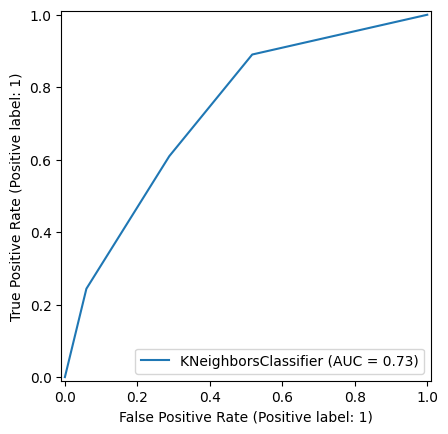

In [ ]:
# Построим ROC-кривую на тестовой выборке
RocCurveDisplay.from_estimator(knn, features_test, target_test)
plt.show()
plt.close()

In [ ]:
# Оценим вероятности на тестовой выборке
knn_prob1  = knn.predict_proba(features_test)[:, 1]
knn2_prob1 = knn2.predict_proba(features_test)[:, 1]
nb_prob1   = nb.predict_proba(features_nb_test)[:, 1]

In [ ]:
# Посчитеаем TPR и FPR при различных порога (thresholds)
knn_FPR, knn_TPR, knn_thresholds    = metrics.roc_curve(target_test, knn_prob1)
knn2_FPR, knn2_TPR, knn2_thresholds = metrics.roc_curve(target_test, knn2_prob1)
nb_FPR, nb_TPR, nb_thresholds       = metrics.roc_curve(target_test, nb_prob1)

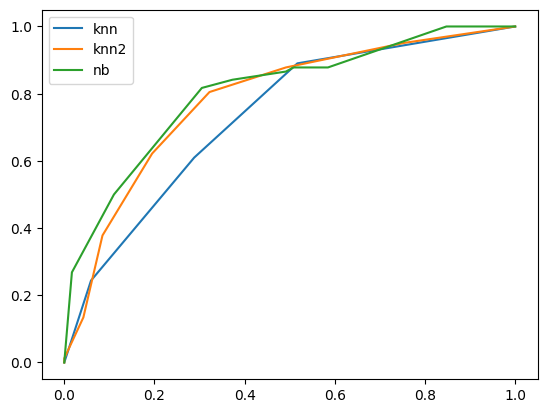

In [ ]:
# Построим ROC-кривые сразу для трех моделей
plt.plot(knn_FPR,  knn_TPR,  label = "knn")
plt.plot(knn2_FPR, knn2_TPR, label = "knn2")
plt.plot(nb_FPR,   nb_TPR,   label = "nb")
plt.legend()
plt.show()

In [ ]:
# Сравним модели по AUC
knn_AUC = metrics.roc_auc_score(target_test, knn_prob1)
knn2_AUC = metrics.roc_auc_score(target_test, knn2_prob1)
nb_AUC = metrics.roc_auc_score(target_test, nb_prob1)
print(pd.DataFrame(data    = [knn_AUC, knn2_AUC, nb_AUC],
                   index   = ['knn', 'knn2', 'nb'],
                   columns = ['AUC']))

           AUC
knn   0.733051
knn2  0.782400
nb    0.804930


**Оценивание выигрыша (gain) и подъема (lift)** 🐱

**Цели** ⭐

*   Обучить метод ближайших соседей с весами на обучающей выборке.
*   Посчитать выигрыш (gain) и подъем (lift) обученного метода на тестовой выборке.
*   Посчитать прибыль.
*   Представить кумулятивный выигрыш и кумулятивный подъем графически.

Техническое примечание ⚡

Для того, чтобы обучить метод ближайших соседей с весами, достаточно установить аргумент `weights = "distance"`. При этом число соседей `n_neighbors` можно взять достаточно большим без опасений серьезного роста смещения, поскольку у более близких соседей будет более высокий вес.

In [ ]:
# Воспользуемся методом ближайших соседей с весами
knn3 = KNeighborsClassifier(n_neighbors = 99,      # число соседей
                            metric = "minkowski",  # метрика расстояния
                            p = 2,                 # Евклидова метрика
                            weights = "distance")  # веса
knn3.fit(features_train, target_train)

KNeighborsClassifier(n_neighbors=99, weights='distance')

In [ ]:
# Создадим набор данных из значений целевой переменной на тестовой
# выборке и соответствующих оценок условных вероятностей
df_gain = pd.DataFrame()
df_gain["target"] = target_test
df_gain["prob"] = knn3.predict_proba(features_test)[:, 1]

Техническое примечание ⚡

Функция `sort_values()` сортирует датафрейм по значениям столбца, название которого указывается в аргументе `by`. При этом если аргумент `ascending = True`, то сортировка происходит в порядке возрастания, а если `ascending = False`, то в порядке убывания (от малых значений к большим).

In [ ]:
# Отсортируем датафрейм по вероятностям
df_gain = df_gain.sort_values(by = "prob", ascending = False)
print(df_gain)

     target  prob
166       0   1.0
128       0   1.0
186       1   1.0
183       1   1.0
96        0   1.0
..      ...   ...
64        1   0.0
125       1   0.0
105       0   0.0
159       1   0.0
172       0   0.0

[200 rows x 2 columns]


Техническое примечание ⚡

Функция `qcut()` возвращает вектор, значения которого определяют, к какой из `q` децилей вектора `x` относится соответствующее наблюдение. Названия этих децилей задаются через аргумент `labels`, где `labels[i]` соответствует названию `i`-й децили.

Убывающая последовательность `labels = range(10, 0, -1)` нужна для того, чтобы определить в первую дециль наибольшие, а не наименьшие значения и т.д., что соответствует традиции расчеты выигрышей и подъемов.

In [ ]:
# Разделим датафрейм на децили
df_gain['decile'] = pd.qcut(x = df_gain['prob'], q = 10,
                            labels = range(10, 0, -1))
print(df_gain)

     target  prob decile
166       0   1.0      1
128       0   1.0      1
186       1   1.0      1
183       1   1.0      1
96        0   1.0      1
..      ...   ...    ...
64        1   0.0     10
125       1   0.0     10
105       0   0.0     10
159       1   0.0     10
172       0   0.0     10

[200 rows x 3 columns]


In [ ]:
# Создадим таблицу для сохранения результатов расчета выигрышей
tbl_gain = pd.DataFrame()

In [ ]:
# Создадим столбец для децилей
tbl_gain["decile"] = range(1, 11)
tbl_gain

,decile
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,10


In [ ]:
# Посчитаем число наблюдений в каждой децили
tbl_gain["obs"] = np.array(df_gain.groupby(
  'decile')['target'].count().sort_index(ascending = False))
print(tbl_gain)

   decile  obs
0       1   20
1       2   20
2       3   20
3       4   20
4       5   20
5       6   20
6       7   20
7       8   20
8       9   20
9      10   20


/tmp/ipykernel_8427/3910441103.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tbl_gain["obs"] = np.array(df_gain.groupby(


In [ ]:
# Рассчитаем число 1, расположенных в соответствующих децилях
tbl_gain["ones"] = np.array(df_gain.groupby(
  'decile')['target'].sum().sort_index(ascending = False))
print(tbl_gain)

   decile  obs  ones
0       1   20    14
1       2   20    16
2       3   20    15
3       4   20    12
4       5   20    10
5       6   20     4
6       7   20     2
7       8   20     2
8       9   20     4
9      10   20     3


/tmp/ipykernel_8427/1216858409.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tbl_gain["ones"] = np.array(df_gain.groupby(


$\text{Выигрыш в }k\text{-й децили} = 100 \times \frac{\text{Число единиц в }k\text{-й децили}}{\text{Общее число единиц в выборке}}$

Показывает процент покупателей, обнаруженных в $k$-й децили. Если бы мы не применяли нашу модель, то этот процент был бы примерно одинаковым по всех децилях. Но благодаря нашей модели мы можем отследить группы наиболее вероятных покупателей, поскольку отсортировали покупателей по величине условных вероятностей покупок.

In [ ]:
# Посчитаем выигрыш
n_ones = np.sum(tbl_gain["ones"])
tbl_gain["gain"] = 100 * tbl_gain["ones"] / n_ones
print(tbl_gain)

   decile  obs  ones       gain
0       1   20    14  17.073171
1       2   20    16  19.512195
2       3   20    15  18.292683
3       4   20    12  14.634146
4       5   20    10  12.195122
5       6   20     4   4.878049
6       7   20     2   2.439024
7       8   20     2   2.439024
8       9   20     4   4.878049
9      10   20     3   3.658537


In [ ]:
# Вычислим кумулятивный выигрыш
tbl_gain["cumulative_gain"] = tbl_gain["gain"].cumsum()
print(tbl_gain)

   decile  obs  ones       gain  cumulative_gain
0       1   20    14  17.073171        17.073171
1       2   20    16  19.512195        36.585366
2       3   20    15  18.292683        54.878049
3       4   20    12  14.634146        69.512195
4       5   20    10  12.195122        81.707317
5       6   20     4   4.878049        86.585366
6       7   20     2   2.439024        89.024390
7       8   20     2   2.439024        91.463415
8       9   20     4   4.878049        96.341463
9      10   20     3   3.658537       100.000000


$\text{Подъем в }k\text{-й децили} = \frac{\text{Число единиц в }k\text{-й децили}}{\text{Число единиц в выборке} / 10}$

Показывает, во сколько раз больше в $k$-й децили мы обнаружили покупателей благодаря нашей модели, чем ожидаемое обнаружили бы, если бы искали их случайным образом, не обращая внимание на оцененные моделью условные вероятности.

In [ ]:
# Рассчитаем лифт
ones_per_decile_random = n_ones / len(tbl_gain)
tbl_gain["lift"] = tbl_gain["ones"] / ones_per_decile_random
print(tbl_gain)

   decile  obs  ones       gain  cumulative_gain      lift
0       1   20    14  17.073171        17.073171  1.707317
1       2   20    16  19.512195        36.585366  1.951220
2       3   20    15  18.292683        54.878049  1.829268
3       4   20    12  14.634146        69.512195  1.463415
4       5   20    10  12.195122        81.707317  1.219512
5       6   20     4   4.878049        86.585366  0.487805
6       7   20     2   2.439024        89.024390  0.243902
7       8   20     2   2.439024        91.463415  0.243902
8       9   20     4   4.878049        96.341463  0.487805
9      10   20     3   3.658537       100.000000  0.365854


In [ ]:
# Посчитаем кумулятивный лифт
cum_ones_per_decile_random = np.repeat(
  ones_per_decile_random, len(tbl_gain)).cumsum()
tbl_gain["cumulative_lift"] = tbl_gain["ones"].cumsum() / cum_ones_per_decile_random
print(tbl_gain)

   decile  obs  ones       gain  cumulative_gain      lift  cumulative_lift
0       1   20    14  17.073171        17.073171  1.707317         1.707317
1       2   20    16  19.512195        36.585366  1.951220         1.829268
2       3   20    15  18.292683        54.878049  1.829268         1.829268
3       4   20    12  14.634146        69.512195  1.463415         1.737805
4       5   20    10  12.195122        81.707317  1.219512         1.634146
5       6   20     4   4.878049        86.585366  0.487805         1.443089
6       7   20     2   2.439024        89.024390  0.243902         1.271777
7       8   20     2   2.439024        91.463415  0.243902         1.143293
8       9   20     4   4.878049        96.341463  0.487805         1.070461
9      10   20     3   3.658537       100.000000  0.365854         1.000000


**Сюжет**

Предположим, что затраты на привлечение потенциального покупателя составляют 2 рубль, а доход с продажи составляют 10 рублей. Покупку могут совершить лишь привлекаемые покупатели, поскольку, например, фирма продает свой товар самостоятельно, персонально связываясь с потенциальными клиентами.

Используемая выборка была получена по результатам случайного обзвона индивидов. Однако, в дальнейшем, фирма хочет оптимизировать процесс обзвона, обращаясь лишь к наиболее вероятным покупателям.

In [ ]:
# Посчитаем выручку, издержки и прибыль
p_revenue           = 10
p_cost              = 2
tbl_gain["revenue"] = tbl_gain["ones"] * p_revenue
tbl_gain["cost"]    = tbl_gain["obs"] * p_cost
tbl_gain["profit"]  = tbl_gain["revenue"] - tbl_gain["cost"]
print(tbl_gain)

   decile  obs  ones       gain  cumulative_gain      lift  cumulative_lift  \
0       1   20    14  17.073171        17.073171  1.707317         1.707317   
1       2   20    16  19.512195        36.585366  1.951220         1.829268   
2       3   20    15  18.292683        54.878049  1.829268         1.829268   
3       4   20    12  14.634146        69.512195  1.463415         1.737805   
4       5   20    10  12.195122        81.707317  1.219512         1.634146   
5       6   20     4   4.878049        86.585366  0.487805         1.443089   
6       7   20     2   2.439024        89.024390  0.243902         1.271777   
7       8   20     2   2.439024        91.463415  0.243902         1.143293   
8       9   20     4   4.878049        96.341463  0.487805         1.070461   
9      10   20     3   3.658537       100.000000  0.365854         1.000000   

   revenue  cost  profit  
0      140    40     100  
1      160    40     120  
2      150    40     110  
3      120    40      

In [ ]:
# Для сопоставления посчитаем прибыль в случае, если бы мы опрашивали
# людей случайным образом, без использования модели
tbl_gain["profit_random"] = (np.sum(tbl_gain["revenue"]) ) / len(tbl_gain) - tbl_gain["cost"]
print(tbl_gain)
#(общая выручка) / (количество групп) - стоимость

   decile  obs  ones       gain  cumulative_gain      lift  cumulative_lift  \
0       1   20    14  17.073171        17.073171  1.707317         1.707317   
1       2   20    16  19.512195        36.585366  1.951220         1.829268   
2       3   20    15  18.292683        54.878049  1.829268         1.829268   
3       4   20    12  14.634146        69.512195  1.463415         1.737805   
4       5   20    10  12.195122        81.707317  1.219512         1.634146   
5       6   20     4   4.878049        86.585366  0.487805         1.443089   
6       7   20     2   2.439024        89.024390  0.243902         1.271777   
7       8   20     2   2.439024        91.463415  0.243902         1.143293   
8       9   20     4   4.878049        96.341463  0.487805         1.070461   
9      10   20     3   3.658537       100.000000  0.365854         1.000000   

   revenue  cost  profit  profit_random  
0      140    40     100           42.0  
1      160    40     120           42.0  
2   

In [ ]:
# Для удобства можно округлить некоторые значения
pd.set_option('display.max_columns', None)
# Устанавливает опцию pandas, чтобы при выводе DataFrame показывались все столбцы без ограничений.



print(np.round(tbl_gain, 2))

   decile  obs  ones   gain  cumulative_gain  lift  cumulative_lift  revenue  \
0       1   20    14  17.07            17.07  1.71             1.71      140   
1       2   20    16  19.51            36.59  1.95             1.83      160   
2       3   20    15  18.29            54.88  1.83             1.83      150   
3       4   20    12  14.63            69.51  1.46             1.74      120   
4       5   20    10  12.20            81.71  1.22             1.63      100   
5       6   20     4   4.88            86.59  0.49             1.44       40   
6       7   20     2   2.44            89.02  0.24             1.27       20   
7       8   20     2   2.44            91.46  0.24             1.14       20   
8       9   20     4   4.88            96.34  0.49             1.07       40   
9      10   20     3   3.66           100.00  0.37             1.00       30   

   cost  profit  profit_random  
0    40     100           42.0  
1    40     120           42.0  
2    40     110     

In [ ]:
df_gain

,target,prob,decile
166,0,1.0,1
128,0,1.0,1
186,1,1.0,1
183,1,1.0,1
96,0,1.0,1
...,...,...,...
64,1,0.0,10
125,1,0.0,10
105,0,0.0,10
159,1,0.0,10


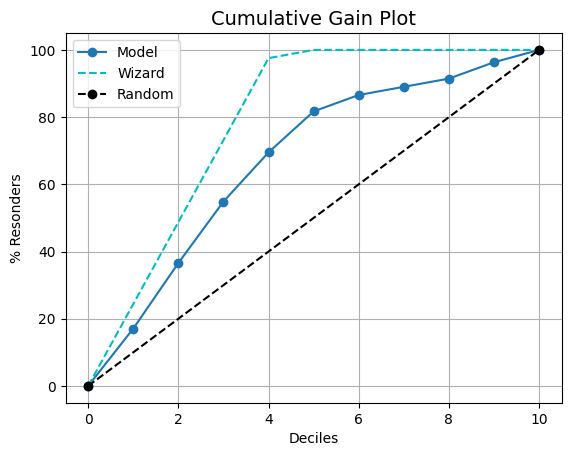

In [ ]:
# Графическая репрезентация кумулятивного выигрыша
kds.metrics.plot_cumulative_gain(df_gain["target"], df_gain["prob"])
plt.show()
plt.close()
# model  - выигрыш модели
# random - выигрыш при случайном выборе
# wizard - выигрыши лучшей из возможных моделей, то есть той, которая
#          оценивает условную вероятность как 1 (0) для всех наблюдений,
#          у которых на самом деле занчение целевой переменной равняется 1 (0).

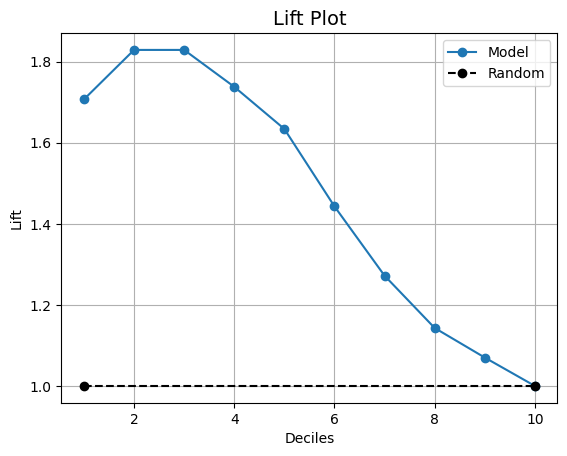

In [ ]:
# Графическая репрезентация кумулятивного лифта
kds.metrics.plot_lift(df_gain["target"], df_gain["prob"])
plt.show()
plt.close()

**Визуализация границ принятия решений** 🐱

**Цели** ⭐

*   Визуализировать границу принятий решений метода ближайших соседей.

In [ ]:
# Обучим метод ближайших соседей на двух признаках
knn4 = KNeighborsClassifier(n_neighbors = 3,
                            metric = "minkowski",
                            p = 2)
knn4.fit(features_train[['age', 'income']], target_train)

KNeighborsClassifier(n_neighbors=3)

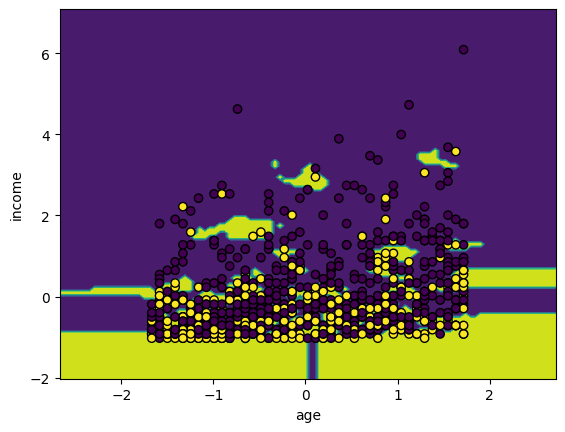

In [ ]:
 # Визуализируем границы принятия решений
 db = DecisionBoundaryDisplay.from_estimator(estimator = knn4,
                                             X = features_train[['age', 'income']],
                                             response_method = "predict",
                                             grid_resolution = 100)
 db.ax_.scatter(features_train['age'], features_train['income'],
                c = target_train, edgecolor = "k")